In [68]:
import argparse
import sys
from pathlib import Path
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from typing import Dict, List, Tuple, Callable, Any, Optional
import wandb

############################################################
# --- Generic Label Functions for Experiment Axes --------- #
############################################################

def make_range_label(label: str) -> Callable[[Any], str]:
    """
    Returns a function that can be used to make human-readable labels for a given range.
    """
    def _label_fn(range_val):
        if range_val is None:
            return "Skip"
        min_val, max_val = range_val
        return f"{label} ({min_val:.2f}-{max_val:.2f})"
    return _label_fn

def get_homophily_label(homophily_range):
    """
    Converts homophily range to a readable label.
    """
    if homophily_range is None:
        return "Skip"
    min_h, max_h = homophily_range
    if min_h >= 0.9:
        return f"High ({min_h:.1f}-{max_h:.1f})"
    elif max_h <= 0.1:
        return f"Low ({min_h:.1f}-{max_h:.1f})"
    elif min_h <= 0.01 and max_h >= 0.99:
        return f"Full ({min_h:.1f}-{max_h:.1f})"
    else:
        return f"Mid ({min_h:.1f}-{max_h:.1f})"

############################################################
# --- Helper Functions ----------------------------------- #
############################################################

def extract_pretrained_model_name(run_dir):
    """
    Extract a short name for the pretrained model from the run directory.
    """
    if run_dir is None:
        return "Unknown"
    run_dir_str = str(run_dir)
    if "run-" in run_dir_str:
        parts = run_dir_str.split("run-")[-1]
        wandb_id = parts.split("-")[-1]
        return wandb_id
    return "Unknown"

def get_family_param_from_override(config: dict, param_key: str) -> Optional[Any]:
    """
    Return value of param_key in config['graphuniverse_override']['family_parameters'], or None.
    """
    gu_override = config.get("graphuniverse_override", None)
    if gu_override and isinstance(gu_override, dict):
        family_params = gu_override.get("family_parameters", {})
        return family_params.get(param_key, None)
    return None

############################################################
# --- Main Data Loading Function: Generalized! ----------- #
############################################################

def load_runs_from_wandb_general(
    experiment: dict,
) -> Tuple[pd.DataFrame, dict]:
    """
    Load runs from wandb project and extract relevant data for a generic experiment.

    Experiment dict parameters:
    - project (str): wandb project name
    - entity (str): wandb entity/team/user
    - tags (list or None)
    - filters (dict or None, optional)
    - pretrained_model_id_map (dict): model_id -> parameter_range mapping (for legend/title)
    - pretrained_model_range_col (str): Name of the range being used for pretraining (e.g., "pretrained_homophily_range")
    - downstream_family_param_key (str): Key to family_parameter for downstream (e.g., "homophily_range", "avg_degree_range")
    - downstream_label_fn (callable): Function mapping downstream_family_range to human label (for x-axes)
    - downstream_label_col (str): Column name for label (e.g., "homophily_label", "deg_label")
    - experiment_label (str): Main experiment name for user output
    - skip_if_downstream_param_none (bool, default=True): Whether to skip runs without downstream value.

    Returns:
        (df, config_example)
    """
    project = experiment["project"]
    entity = experiment.get("entity", None)
    tags = experiment.get("tags", None)
    filters = experiment.get("filters", None)
    pretrained_model_id_map = experiment["pretrained_model_id_map"]  # dict mapping model id to range/param info
    pretrained_model_range_col = experiment["pretrained_model_range_col"]
    downstream_family_param_key = experiment["downstream_family_param_key"]
    downstream_label_fn = experiment["downstream_label_fn"]
    downstream_label_col = experiment["downstream_label_col"]
    experiment_label = experiment.get("experiment_label", project)
    skip_if_downstream_param_none = experiment.get("skip_if_downstream_param_none", True)

    print(f"\n{'='*80}")
    print(f"LOADING RUNS FROM WANDB: {experiment_label}")
    print(f"{'='*80}")
    print(f"Project: {project}")
    if entity:
        print(f"Entity: {entity}")
    if tags:
        print(f"Tags: {tags}")

    # Initialize wandb API and filters
    api = wandb.Api()
    project_path = f"{entity}/{project}" if entity else project
    wandb_filters = filters or {}
    if tags:
        wandb_filters["tags"] = {"$in": tags}

    print(f"\nFetching runs...")
    runs = api.runs(project_path, filters=wandb_filters)
    print(f"Found {len(runs)} runs")

    data = []
    config_example = None
    for run in runs:
        try:
            config = run.config
            if config_example is None:
                config_example = config
            summary = run.summary

            pretrained_run_dir = config.get("pretraining_run", None)
            pretrained_model = extract_pretrained_model_name(pretrained_run_dir)
            # Look up pretraining param/range info from provided mapping (must succeed)
            pretrained_model_range = pretrained_model_id_map.get(pretrained_model, None)

            # Get downstream test parameter
            downstream_param = get_family_param_from_override(config, downstream_family_param_key)

            # Label (for x-axis): typically a readable version of downstream_param
            downstream_label = downstream_label_fn(downstream_param)

            mode = config.get("mode", "unknown")
            test_accuracy = summary.get("test/accuracy", None)
            test_mae = summary.get("test/mae", None)
            n_train = config.get("n_train", None)
            n_evaluation_graphs = config.get("n_evaluation_graphs", None)
            task_type = config.get("task_type", "classification")
            task_level = config.get("task_level", "node")

            # Optionally skip runs with missing downstream parameter (configurable)
            if skip_if_downstream_param_none and downstream_param is None:
                continue

            row = {
                "run_id": run.id,
                "run_name": run.name,
                "pretrained_model": pretrained_model,
                pretrained_model_range_col: pretrained_model_range,
                downstream_family_param_key: downstream_param,
                downstream_label_col: downstream_label,
                "mode": mode,
                "test_accuracy": test_accuracy,
                "test_mae": test_mae,
                "n_train": n_train,
                "n_evaluation_graphs": n_evaluation_graphs,
                "task_type": task_type,
                "task_level": task_level,
                "pretrained_run_dir": pretrained_run_dir,
            }
            data.append(row)
        except Exception as e:
            print(f"Warning: Failed to process run {getattr(run,'id',str(run))}: {e}")
            continue

    df = pd.DataFrame(data)

    # Print experiment summary
    print(f"\n{'='*80}")
    print(f"DATA SUMMARY: {experiment_label}")
    print(f"{'='*80}")
    print(f"Total runs loaded: {len(df)}")
    print(f"Unique pretrained models: {df['pretrained_model'].nunique()}")
    print(f"Unique downstream labels: {df[downstream_label_col].nunique()}")
    print(f"Unique modes: {df['mode'].nunique()}")
    print(f"\nPretrained models: {sorted(df['pretrained_model'].unique())}")
    print(f"Downstream labels: {sorted(df[downstream_label_col].dropna().unique())}")
    print(f"Modes: {sorted(df['mode'].unique())}")
    print(f"{'='*80}\n")

    return df, config_example

############################################################
# --- Generalized Plotting Functions ----------------------#
############################################################
def plot_grouped_bars_general(
    df: pd.DataFrame,
    output_path: str,
    model_range_col: str,
    downstream_label_col: str,
    metric: str = "test_accuracy",
    figsize: Tuple[int, int] = (20, 5),
    included_modes: list = None,
):
    """
    Create grouped bar plots for generic experiment.
    - included_modes: If specified, only include these modes (in this order) if present in the data.
      Default (None): use all available modes in the data, but order as specified in MAX_MODES if present.
    """
    # Define the maximum set and preferred order of modes
    MAX_MODES_ORDER = [
        "finetune",
        "scratch",
        "linear",
        "gpf-linear",
        "gpf-plus-linear",
        "untrained_frozen"
    ]

    print(f"\n{'='*80}")
    print(f"CREATING GROUPED BAR PLOTS (multi-row by n_train/finetune size)")
    print(f"{'='*80}")

    pretrained_models = sorted(df['pretrained_model'].unique())
    n_models = len(pretrained_models)
    finetune_sizes = sorted(df['n_train'].dropna().unique())
    n_finetune = len(finetune_sizes)

    print(f"Creating grid: {n_finetune} row(s) (finetune sizes: {finetune_sizes}), {n_models} col(s) for pretrained models: {pretrained_models}")

    if metric == "test_accuracy":
        metric_col = "test_accuracy"
        ylabel = "Test Accuracy"
        min_ylim = 0
    else:
        metric_col = "test_mae"
        ylabel = "Test MAE"
        min_ylim = 0

    # --- Compute max value across all runs for this metric ---
    max_val_all = df[metric_col].max()
    ylim_max = max_val_all * 1.1  # Add 10% headroom
    if metric == "test_accuracy":
        ylim_max = min(1.0, ylim_max)  # don't exceed 1.0 for accuracy
    ylim = (min_ylim, ylim_max)

    print(f"Setting y-axis limits: {ylim} (max value found={max_val_all:.4f})")

    fig, axes = plt.subplots(
        n_finetune, n_models,
        figsize=(figsize[0], figsize[1] * n_finetune),
        sharey=True,
        squeeze=False
    )

    # Determine which modes to include and in which order
    available_modes = list(df['mode'].dropna().unique())
    if included_modes is not None:
        # Only include those in both included_modes AND in the data, in the specified order
        all_modes = [m for m in included_modes if m in available_modes]
    else:
        # Use all available in data, and order as in MAX_MODES_ORDER, then add any unknowns at end
        ordered_modes = [m for m in MAX_MODES_ORDER if m in available_modes]
        extras = [m for m in available_modes if m not in MAX_MODES_ORDER]
        all_modes = ordered_modes + sorted(extras)

    mode_colors = plt.cm.tab10(np.linspace(0, 1, max(1, len(all_modes))))
    mode_color_map = dict(zip(all_modes, mode_colors))

    for row_idx, n_train in enumerate(finetune_sizes):
        for col_idx, pretrained_model in enumerate(pretrained_models):
            ax = axes[row_idx][col_idx]

            this_df = df[
                (df['pretrained_model'] == pretrained_model) &
                (df['n_train'] == n_train)
            ]
            if len(this_df) == 0:
                ax.axis("off")
                continue

            # Pretraining range value (for title)
            pretrain_range = this_df.iloc[0][model_range_col] if model_range_col in this_df.columns else None

            print(f"\nProcessing model: {pretrained_model}, finetune size: {n_train} ({len(this_df)} runs)")

            grouped = this_df.groupby([downstream_label_col, 'mode'])[metric_col].mean().reset_index()
            downstream_labels = sorted(grouped[downstream_label_col].unique())
            x_positions = np.arange(len(downstream_labels))
            bar_width = 0.8 / max(1, len(all_modes))

            for mode_idx, mode in enumerate(all_modes):
                mode_data = grouped[grouped['mode'] == mode]
                values = []
                for label in downstream_labels:
                    mode_label_data = mode_data[mode_data[downstream_label_col] == label]
                    if len(mode_label_data) > 0:
                        values.append(mode_label_data[metric_col].values[0])
                    else:
                        values.append(np.nan)
                offset = (mode_idx - len(all_modes)/2 + 0.5) * bar_width
                bars = ax.bar(
                    x_positions + offset,
                    values,
                    bar_width,
                    label=mode,
                    color=mode_color_map[mode],
                    alpha=0.8,
                    edgecolor='black',
                    linewidth=0.5,
                )
                for bar, val in zip(bars, values):
                    if not np.isnan(val):
                        height = bar.get_height()
                        ax.text(
                            bar.get_x() + bar.get_width()/2.,
                            height + 0.012 * ylim_max,
                            f'{val:.3f}',
                            ha='center',
                            va='bottom',
                            fontsize=7,
                            rotation=90,
                        )

            if row_idx == n_finetune - 1:
                ax.set_xlabel(downstream_label_col.replace("_", " ").title(), fontsize=12, fontweight='bold')
            if col_idx == 0:
                ax.set_ylabel(f'{ylabel}\n\nFinetune size = {n_train}', fontsize=12, fontweight='bold')
            else:
                ax.set_ylabel(None)

            # Slightly more generic title
            title_str = f'Pretrain Range: {pretrain_range}' if pretrain_range is not None else pretrained_model
            ax.set_title(title_str, fontsize=13, fontweight='bold')
            ax.set_xticks(x_positions)
            ax.set_xticklabels(downstream_labels, rotation=45, ha='right', fontsize=9)
            ax.grid(axis='y', alpha=0.3, linestyle='--')
            ax.set_ylim(ylim)
            if (row_idx == 0 and col_idx == n_models - 1):
                ax.legend(
                    loc='upper left',
                    bbox_to_anchor=(1.02, 1),
                    fontsize=9,
                    title='Mode',
                    title_fontsize=10,
                )

    for row_idx, n_train in enumerate(finetune_sizes):
        ax = axes[row_idx][0]
        ax.annotate(
            f"Finetune size: {n_train}",
            xy=(-0.33, 0.5), xycoords='axes fraction',
            fontsize=15, fontweight='bold', va='center', ha='right',
            rotation=90, annotation_clip=False,
        )

    fig.suptitle(
        f'Downstream Evaluation: {ylabel} by {downstream_label_col.replace("_"," ").title()} and Mode\n(Broken down by finetune size, row=finetune size, col=pretrained model)',
        fontsize=17,
        fontweight='bold',
        y=1.03,
    )

    plt.tight_layout(rect=[0, 0, 1, 0.98])
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"\n✓ Saved figure to {output_path}")
    plt.show()


def plot_n_train_curves_general(
    df: pd.DataFrame,
    output_path: str,
    model_range_col: str,
    downstream_label_col: str,
    metric: str = "test_accuracy",
    figsize: Tuple[int, int] = (20, 5),
):
    """
    Create line plots showing how performance changes with n_train for a generic experiment.
    """
    print(f"\n{'='*80}")
    print(f"CREATING N_TRAIN CURVES")
    print(f"{'='*80}")
    pretrained_models = sorted(df['pretrained_model'].unique())
    n_models = len(pretrained_models)

    if metric == "test_accuracy":
        metric_col = "test_accuracy"
        ylabel = "Test Accuracy"
    else:
        metric_col = "test_mae"
        ylabel = "Test MAE"

    fig, axes = plt.subplots(1, n_models, figsize=figsize, sharey=True)
    if n_models == 1:
        axes = [axes]

    all_modes = sorted(df['mode'].unique())
    mode_colors = plt.cm.tab10(np.linspace(0, 1, len(all_modes)))
    mode_color_map = dict(zip(all_modes, mode_colors))

    line_styles = ['-', '--', '-.', ':']

    for idx, (pretrained_model, ax) in enumerate(zip(pretrained_models, axes)):
        model_df = df[df['pretrained_model'] == pretrained_model].copy()
        downstream_labels = sorted(model_df[downstream_label_col].unique())
        for mode_idx, mode in enumerate(all_modes):
            for l_idx, label in enumerate(downstream_labels):
                subset = model_df[
                    (model_df['mode'] == mode) & 
                    (model_df[downstream_label_col] == label)
                ].copy()
                if len(subset) == 0:
                    continue
                subset = subset.sort_values('n_train')
                linestyle = line_styles[l_idx % len(line_styles)]
                ax.plot(
                    subset['n_train'],
                    subset[metric_col],
                    marker='o',
                    linestyle=linestyle,
                    color=mode_color_map[mode],
                    label=f"{mode} - {label}",
                    linewidth=2,
                    markersize=6,
                    alpha=0.8,
                )
        ax.set_xlabel('N Train', fontsize=12, fontweight='bold')
        if idx == 0:
            ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
        title_val = model_df.iloc[0][model_range_col] if model_range_col in model_df and len(model_df)>0 else pretrained_model
        ax.set_title(f'Model: {pretrained_model}\n{model_range_col}: {title_val}', fontsize=13, fontweight='bold')
        ax.grid(alpha=0.3, linestyle='--')
        ax.set_xscale('log')
        if idx == n_models - 1:
            ax.legend(
                loc='upper left',
                bbox_to_anchor=(1.02, 1),
                fontsize=8,
                title=f"Mode - {downstream_label_col.replace('_',' ').title()}",
                title_fontsize=9,
            )
    fig.suptitle(
        f'Downstream Evaluation: {ylabel} vs Training Set Size',
        fontsize=16,
        fontweight='bold',
        y=1.02,
    )
    plt.tight_layout()
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"\n✓ Saved figure to {output_path}")
    plt.show()

############################################################
# --- Example Experiment DEFINITION Dicts -----------------#
############################################################

EXPERIMENTS: Dict[str, dict] = {
    "homophily": {
        "project": "graphmaev2_downstream_eval_grid",
        "entity": "louis-van-langendonck-universitat-polit-cnica-de-catalunya",
        "tags": None,
        "filters": None,
        "pretrained_model_id_map": {
            "1ldqko00": [0.0, 0.1],
            "xgunct31": [0.0, 1.0],
            "wknkovg3": [0.4, 0.6],
            "ydo2c2tz": [0.9, 1.0],
        },
        "pretrained_model_range_col": "pretrained_homophily_range",
        "downstream_family_param_key": "homophily_range",
        "downstream_label_fn": get_homophily_label,
        "downstream_label_col": "homophily_label",
        "experiment_label": "Homophily",
        "skip_if_downstream_param_none": True,
    },
    "avg_degree": {
        "project": "graphmaev2_downstream_avg_degree_test",
        "entity": "louis-van-langendonck-universitat-polit-cnica-de-catalunya",
        "tags": None,
        "filters": None,
        "pretrained_model_id_map": {
            "wknkovg3": [1,3],
            "fxszphts": [5,6],
            "ofs1ap51": [1,6],
        },
        "pretrained_model_range_col": "pretrained_avg_degree_range",
        "downstream_family_param_key": "avg_degree_range",
        "downstream_label_fn": make_range_label("Deg"),
        "downstream_label_col": "deg_label",
        "experiment_label": "Avg Degree",
        "skip_if_downstream_param_none": True,
    },
    "powerlaw": {
        "project": "graphmaev2_downstream_avg_power_law_test",
        "entity": "louis-van-langendonck-universitat-polit-cnica-de-catalunya",
        "tags": None,
        "filters": None,
        "pretrained_model_id_map": {
            "wknkovg3": [1.5,2.5],
            "d4z4b1sl": [4,5],
            "9g7lmhhl": [1.5,5],
        },
        "pretrained_model_range_col": "pretrained_power_law_exponent_range",
        "downstream_family_param_key": "power_law_exponent_range",
        "downstream_label_fn": make_range_label("Powerlaw"),
        "downstream_label_col": "powerlaw_label",
        "experiment_label": "Powerlaw exponent",
        "skip_if_downstream_param_none": True,
    },
    "n_nodes": {
        "project": "graphmaev2_downstream_eval_nnodes",
        "entity": "louis-van-langendonck-universitat-polit-cnica-de-catalunya",
        "tags": None,
        "filters": None,
        "pretrained_model_id_map": {
            "wknkovg3": [50,150],
            "gym2dxkn": [50,350],
            "ucw55gfx": [300,350],
        },
        "pretrained_model_range_col": "pretrained_n_nodes_range",
        "downstream_family_param_key": "n_nodes_range",
        "downstream_label_fn": make_range_label("NNodes"),
        "downstream_label_col": "nnodes_label",
        "experiment_label": "N Nodes",
        "skip_if_downstream_param_none": True,
    },
}

INCLUDED_MODES = ['finetune','linear','scratch'] #['linear', 'gpf-linear', 'gpf-plus-linear', 'untrained_frozen']#['finetune', 'scratch', 'untrained_frozen'] #['finetune', 'scratch', 'linear', 'gpf-linear', 'gpf-plus-linear', 'untrained_frozen']
EXPERIMENT_NAME_TO_PLOT = "homophily"
DEFAULT_OUTPUT_DIR = "results"
DEFAULT_FORMAT = "PNG"
DEFAULT_METRIC = "test_accuracy"
DEFAULT_FIGSIZE = (20, 5)
DEFAULT_NO_N_TRAIN_PLOT = False



LOADING RUNS FROM WANDB: Homophily
Project: graphmaev2_downstream_eval_grid
Entity: louis-van-langendonck-universitat-polit-cnica-de-catalunya

Fetching runs...
Found 342 runs

DATA SUMMARY: Homophily
Total runs loaded: 324
Unique pretrained models: 4
Unique downstream labels: 4
Unique modes: 6

Pretrained models: ['1ldqko00', 'wknkovg3', 'xgunct31', 'ydo2c2tz']
Downstream labels: ['Full (0.0-1.0)', 'High (0.9-1.0)', 'Low (0.0-0.1)', 'Mid (0.4-0.6)']
Modes: ['finetune', 'gpf-linear', 'gpf-plus-linear', 'linear', 'scratch', 'untrained_frozen']


CREATING GROUPED BAR PLOTS (multi-row by n_train/finetune size)
Creating grid: 3 row(s) (finetune sizes: [5, 50, 100]), 4 col(s) for pretrained models: ['1ldqko00', 'wknkovg3', 'xgunct31', 'ydo2c2tz']
Setting y-axis limits: (0, 0.72616303005352) (max value found=0.6601)

Processing model: 1ldqko00, finetune size: 5 (24 runs)

Processing model: wknkovg3, finetune size: 5 (24 runs)

Processing model: xgunct31, finetune size: 5 (36 runs)

Processi

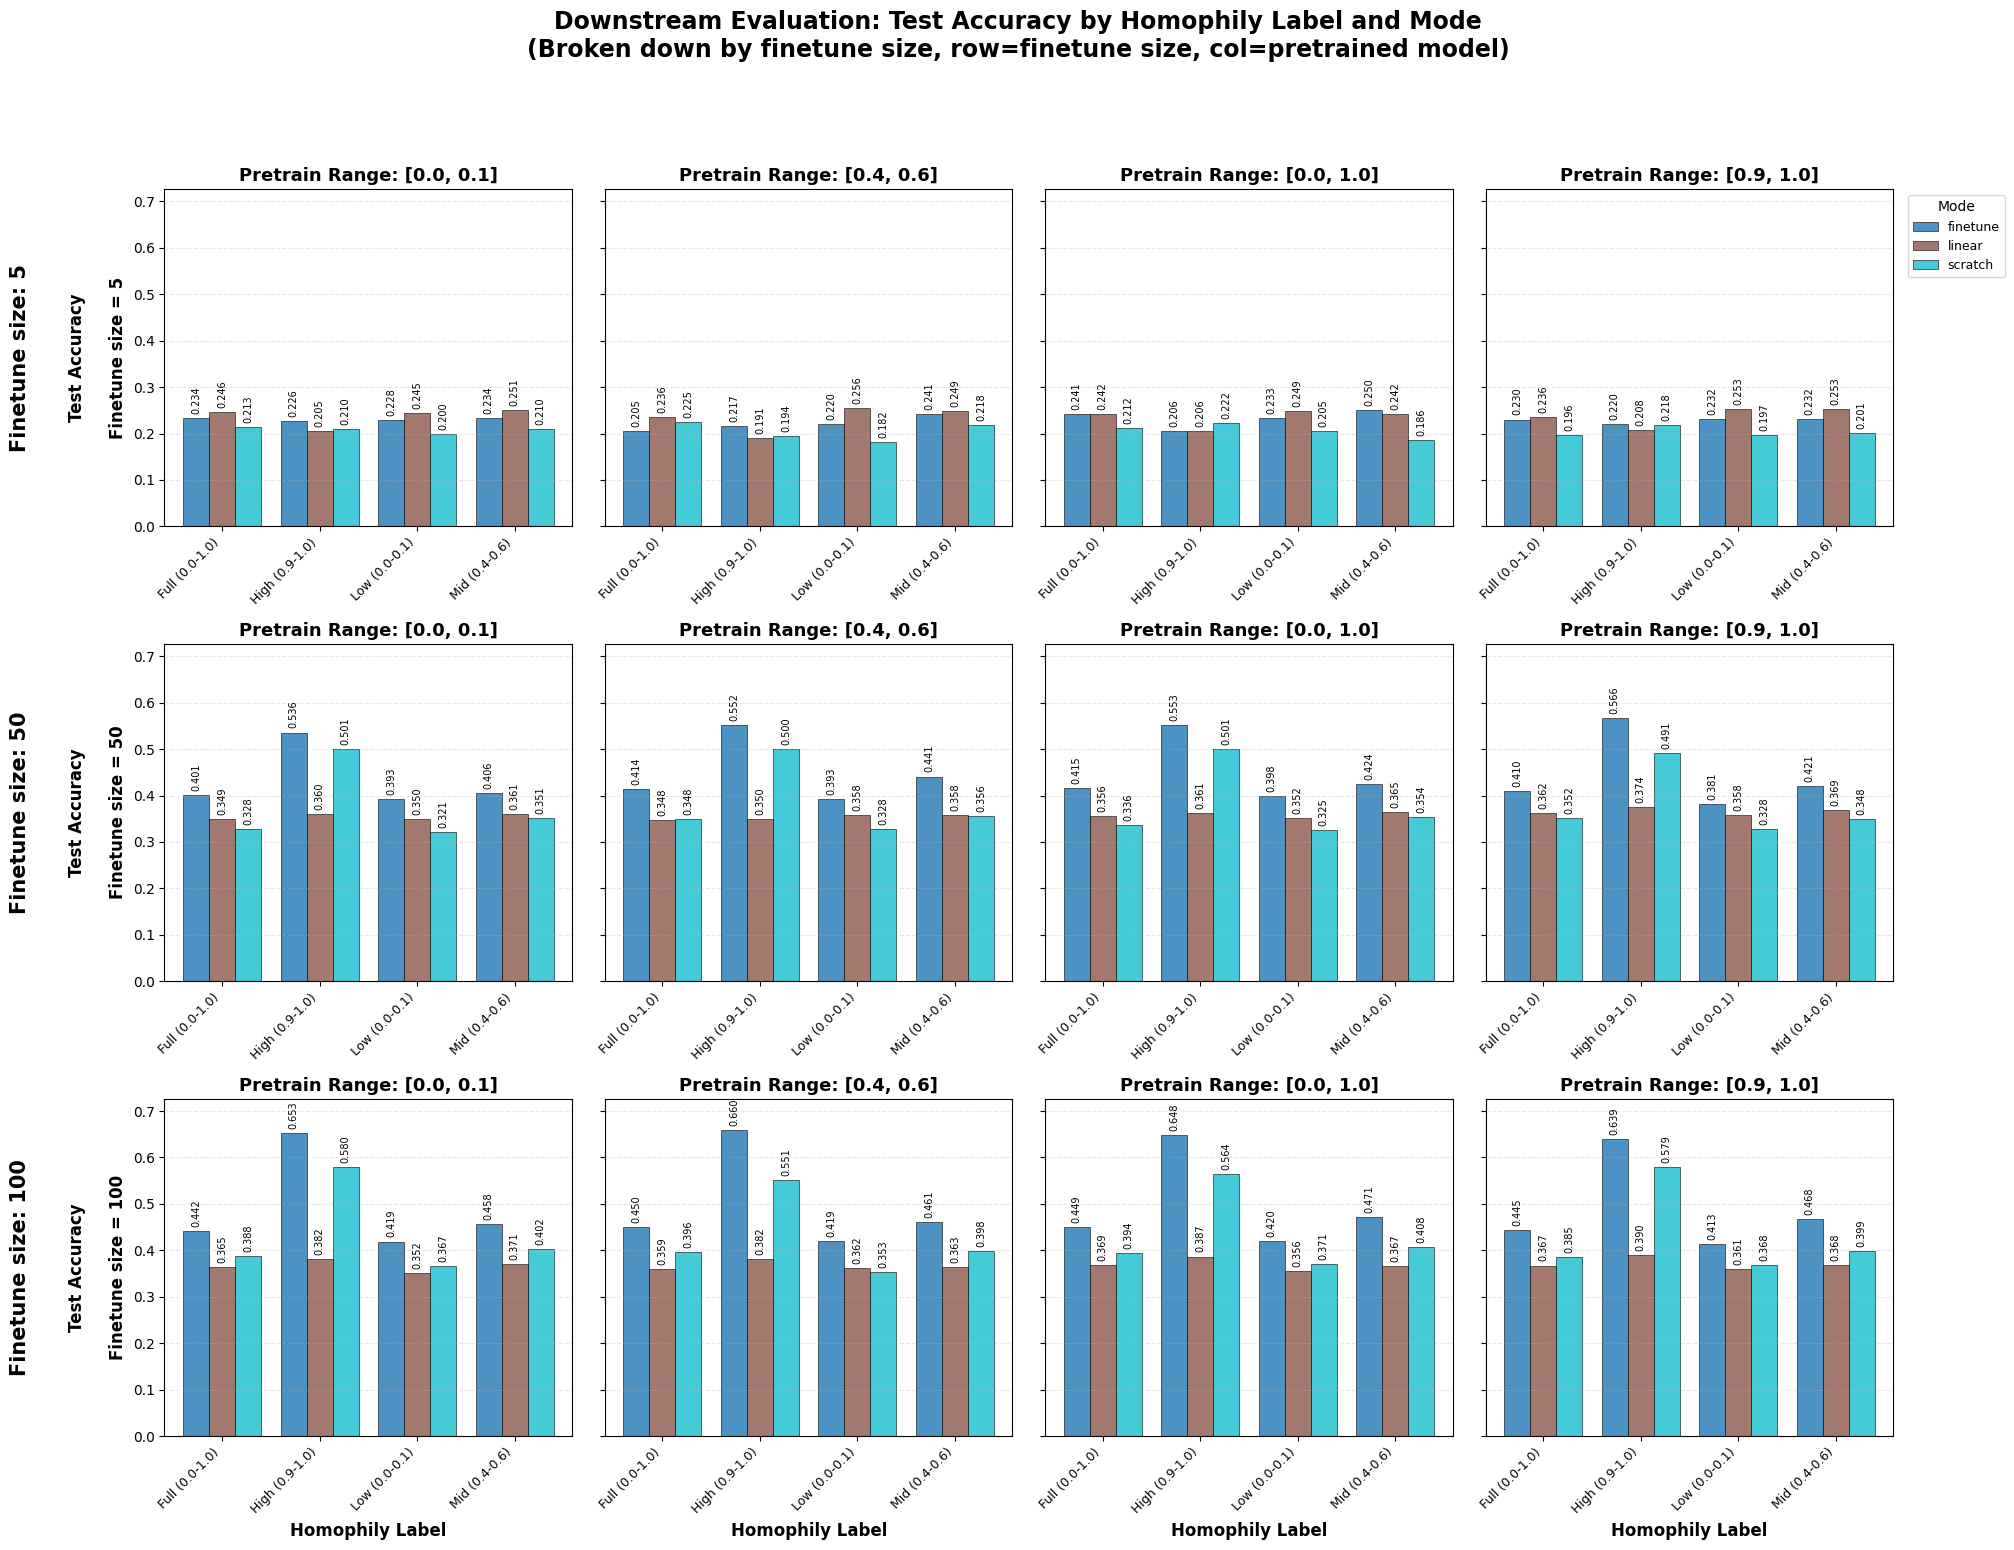

In [69]:

# Load runs from wandb
df, config_example = load_runs_from_wandb_general(
    experiment=EXPERIMENTS[EXPERIMENT_NAME_TO_PLOT],
)

if len(df) == 0:
    print("ERROR: No runs found in the specified project")

plot_grouped_bars_general(
    df=df,
    output_path=str(grouped_bar_path),
    model_range_col=EXPERIMENTS[EXPERIMENT_NAME_TO_PLOT]["pretrained_model_range_col"],
    downstream_label_col=EXPERIMENTS[EXPERIMENT_NAME_TO_PLOT]["downstream_label_col"],
    figsize=tuple(FIGSIZE),
    metric=METRIC,
    included_modes=INCLUDED_MODES,
)